# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** ☑ Standard Analysis ☐ Research-Oriented  
**Group members:**  
- Tereza Knápková
- Mária Matušisková
- Dominik Kysel
- Dominik Ott   

**Dataset:** 
- Bike Sharing Dataset (https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

**Initial task description (Module 1 perspective):**
RESEARCH QUESTIONS:
- RQ1: Which temporal and weather factors are most associated with hourly bike demand (`cnt`)?
- RQ2: Can clustering reveal distinct bike-usage regimes (e.g., commute, leisure, low-demand periods)?
- TODO: 

## 0. Reproducibility and Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo 

## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- Number of instances: 17,379 hourly records 
- Number of features / entities: 17 variables in the hourly table
- Missing values: 0 missing values in the loaded hourly table
- Basic statistics: summarized in the following output tables


In [4]:
bike_sharing = fetch_ucirepo(id=275)

print(f"Dataset {bike_sharing.metadata['name']}")
print(f"Description: {bike_sharing.metadata['abstract']}")
print(f"Created {bike_sharing.metadata['year_of_dataset_creation']}")
# data
df = bike_sharing.data.original
df.head()


Dataset Bike Sharing
Description: This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.
Created 2013


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns}")
print(f"missing values: {df.isnull().sum()}")



Dataset shape: (17379, 17)
Dataset columns: Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')
missing values: instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


There are 17 columns:
- **instant:** record index
- **dteday:** date
- **season:** 1:spring, 2:summer, 3:fall, 4:winter
- **yr:** year (0: 2011, 1: 2012)
- **mnth:** month (1 to 12)
- **hr:** hour (0 to 23)
- **holiday:** whether the day is a holiday (from the Washington, D.C. holiday calendar)
- **weekday:** day of the week
- **workingday:** 1 if the day is neither weekend nor holiday, otherwise 0
- **weathersit:**
  - 1: Clear, Few clouds, Partly cloudy
  - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog
- **temp:** normalized temperature in Celsius, scaled from t_min = -8 to t_max = +39 (hourly)
- **atemp:** normalized feeling temperature in Celsius, scaled from t_min = -16 to t_max = +50 (hourly)
- **hum:** normalized humidity (divided by 100)
- **windspeed:** normalized wind speed (divided by 67)
- **casual:** count of casual users
- **registered:** count of registered users
- **cnt:** total count of rented bikes (casual + registered)

In [6]:
print(f"Dataset basic statistics:")
df.describe()

Dataset basic statistics:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Where:
- **count** - number of non-null values in each column (here, 17,379 for the hourly table)
- **mean** - average value in each column
- **std** - standard deviation (how spread out the values are around the mean)
- **min** - smallest value in each column
- **25%** - value at the first quartile
- **50%** - median value
- **75%** - value at the third quartile
- **max** - largest value in each column

### Exploratory Data Analysis
- Basic statistics
- Distributions
- Sparsity / density

### Cleaning & Transformations
- Handling missing values
- Feature engineering
- Graph construction (if Checkpoint 2)

Justify design decisions.

## Data Cleaning

Drop non-informative columns:
- **instant:** sequential index with no analytical signal
- **dteday:** raw date string; temporal structure is captured by engineered time features (e.g., hour, month, weekday)

In [7]:
df_clean = df.drop(columns=[ "dteday", "instant"])

print(f"Columns after cleaning: {df_clean.columns.tolist()}")
print(f"Shape: {df_clean.shape}")

Columns after cleaning: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
Shape: (17379, 15)


Validate data integrity for data consistency issues: casual users + registered users should equal total count

In [8]:
validation_error = (df_clean["casual"] + df_clean["registered"] - df_clean["cnt"]).abs().sum()

print(f"Data integrity check (should be 0): {validation_error}")

if validation_error == 0:
    print("Data is consistent: casual + registered = cnt")
else:
    print("Data is inconsistent!")

Data integrity check (should be 0): 0
Data is consistent: casual + registered = cnt


## Encode Categorical Variables

In [9]:
season_labels = {1: "winter", 2: "spring", 3: "summer", 4: "fall"}
year_labels = {0: "2011", 1: "2012"}
weekday_labels = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"}
weathersit_labels = {1: "Clear/Few clouds", 2: "Mist/Cloudy", 3: "Light Snow/Rain", 4: "Heavy Rain/Snow"}

season_dummies = pd.get_dummies(df_clean["season"].map(season_labels), prefix="season")
year_dummies = pd.get_dummies(df_clean["yr"].map(year_labels), prefix="year")
weekday_dummies = pd.get_dummies(df_clean["weekday"].map(weekday_labels), prefix="weekday")
weathersit_dummies = pd.get_dummies(df_clean["weathersit"].map(weathersit_labels), prefix="weathersit")

df_encoded = pd.concat([
    df_clean.drop(columns=["season", "weathersit", "weekday", "yr"]),
    season_dummies,
    year_dummies,
    weekday_dummies,
    weathersit_dummies
], axis=1)

print(f"Columns after encoding: {df_encoded.columns.tolist()}")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nData types:\n{df_encoded.dtypes}")

Columns after encoding: ['mnth', 'hr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'year_2011', 'year_2012', 'weekday_Friday', 'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday', 'weekday_Tuesday', 'weekday_Wednesday', 'weathersit_Clear/Few clouds', 'weathersit_Heavy Rain/Snow', 'weathersit_Light Snow/Rain', 'weathersit_Mist/Cloudy']
Shape after encoding: (17379, 28)

Data types:
mnth                             int64
hr                               int64
holiday                          int64
workingday                       int64
temp                           float64
atemp                          float64
hum                            float64
windspeed                      float64
casual                           int64
registered                       int64
cnt                              int64
season_fall                       bool
season_spr

## Feature Scaling

## K-means

## 2. Module 1 — Vector-Space Analysis

Standardize numerical features to zero mean and unit variance to make scales comparable across variables.

- This reduces dominance of large-scale variables in distance-based methods.
- The `hr` variable is kept unscaled in this version because time-of-day can be handled with cyclical encoding (`sin`/`cos`) in later steps.

In [10]:
scaler = StandardScaler()

numerical_cols = [
    "temp", "atemp", "hum", "windspeed",
    "cnt", "casual", "registered"
]

df_encoded[numerical_cols] = scaler.fit_transform(
    df_encoded[numerical_cols]
)

print("Scaling verification (should be ~0 mean, ~1 std):")
print(f"\nMeans:\n{df_encoded[numerical_cols].mean().round(4)}")
print(f"\nStd Devs:\n{df_encoded[numerical_cols].std().round(4)}")
print(f"\nNote: 'hr' column kept unscaled (range 0-23)")

Scaling verification (should be ~0 mean, ~1 std):

Means:
temp          0.0
atemp        -0.0
hum           0.0
windspeed     0.0
cnt          -0.0
casual        0.0
registered   -0.0
dtype: float64

Std Devs:
temp          1.0
atemp         1.0
hum           1.0
windspeed     1.0
cnt           1.0
casual        1.0
registered    1.0
dtype: float64

Note: 'hr' column kept unscaled (range 0-23)


## Final Dataset Check

In [11]:
# Final cleaned and processed dataset
print("Dataset Overview:")
print(f"Shape: {df_encoded.shape}")
print(f"\nFirst 5 rows:")
print(df_encoded.head())
print(f"\nData Info:")
df_encoded.info()
print(f"\nBasic Statistics:")
print(df_encoded.describe().round(3))

Dataset Overview:
Shape: (17379, 28)

First 5 rows:
   mnth  hr  holiday  workingday      temp     atemp       hum  windspeed  \
0     1   0        0           0 -1.334648 -1.093281  0.947372  -1.553889   
1     1   1        0           0 -1.438516 -1.181732  0.895539  -1.553889   
2     1   2        0           0 -1.438516 -1.181732  0.895539  -1.553889   
3     1   3        0           0 -1.334648 -1.093281  0.636370  -1.553889   
4     1   4        0           0 -1.334648 -1.093281  0.636370  -1.553889   

     casual  registered  ...  weekday_Monday  weekday_Saturday  \
0 -0.662755   -0.930189  ...           False              True   
1 -0.561343   -0.804655  ...           False              True   
2 -0.622190   -0.837690  ...           False              True   
3 -0.662755   -0.950010  ...           False              True   
4 -0.723603   -1.009474  ...           False              True   

   weekday_Sunday  weekday_Thursday  weekday_Tuesday  weekday_Wednesday  \
0           F

### 2.1 Vector Representation

Each hourly record is represented as a numeric feature vector after cleaning, encoding, and scaling.

- **Weather-impact vector (`X_weather`)** uses weather variables plus demand context (`cnt`) for exploratory structure analysis.
- **User-behavior vector (`X_users`)** uses hour with user counts (`casual`, `registered`) to capture usage composition over time.

Distance-based analysis in this module uses Euclidean distance, which is appropriate for standardized continuous features and aligns with K-Means assumptions.

For predictive modeling sections, `cnt` is treated as the target variable and is excluded from predictors to avoid leakage.

In [12]:
# Weather Impact Vector:
X_weather = df_encoded[["temp", "atemp", "hum", "windspeed", "cnt"]].values

# User Segmentation Vector
X_users = df_encoded[["hr", "casual", "registered"]].values

print(f"X_weather shape: {X_weather.shape} - Weather impact on bike usage")
print(f"X_users shape: {X_users.shape} - User type segmentation by hour")

X_weather shape: (17379, 5) - Weather impact on bike usage
X_users shape: (17379, 3) - User type segmentation by hour


### 2.2 Clustering Method

This section applies baseline clustering methods to the constructed vectors and compares cluster quality.

Planned reporting items:
- chosen algorithm and parameters
- validation metric(s) (e.g., silhouette score)
- interpretation of discovered cluster profiles

### Commute pattern clusters (hourly behavior)
- Features: hr, workingday, casual, registered, cnt
- Likely clusters: morning commute peak, evening commute peak, off-peak low demand, late-night minimal deman

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


features  = ["hr", "casual", "registered"]
X = df_clean[features].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

k_values  = range(2, 10)
silhouette_scores = []

for k in k_values:
    k_means = KMeans(n_clusters=k)
    labels = k_means.fit_predict(X)
    silhouette_scores.append(silhouette_score(X,labels))

best_k = k_values[np.argmax(silhouette_scores)]
print("Silhouette by k:", dict(zip(k_values, np.round(silhouette_scores, 4))))
print("Best k:", best_k)


k_means_hourly = KMeans(n_clusters=best_k)
df_clean["cluster_hourly"] = k_means_hourly.fit_predict(X)

profile = (
    df_clean
    .groupby("cluster_hourly")[["hr", "casual", "registered", "cnt", "workingday", "holiday"]]
    .mean()
    .round(2)
    .sort_values("cnt", ascending=False)
)

print("\nHourly behavior cluster profiles:")
print(profile)




Silhouette by k: {2: np.float64(0.3986), 3: np.float64(0.4319), 4: np.float64(0.4659), 5: np.float64(0.4513), 6: np.float64(0.4412), 7: np.float64(0.4359), 8: np.float64(0.4546), 9: np.float64(0.4355)}
Best k: 4

Hourly behavior cluster profiles:
                   hr  casual  registered     cnt  workingday  holiday
cluster_hourly                                                        
0               13.93   51.03      463.32  514.34        0.96     0.01
3               14.29  170.10      271.86  441.96        0.12     0.06
1               16.74   32.58      141.97  174.55        0.73     0.03
2                4.27    6.24       44.38   50.62        0.66     0.03


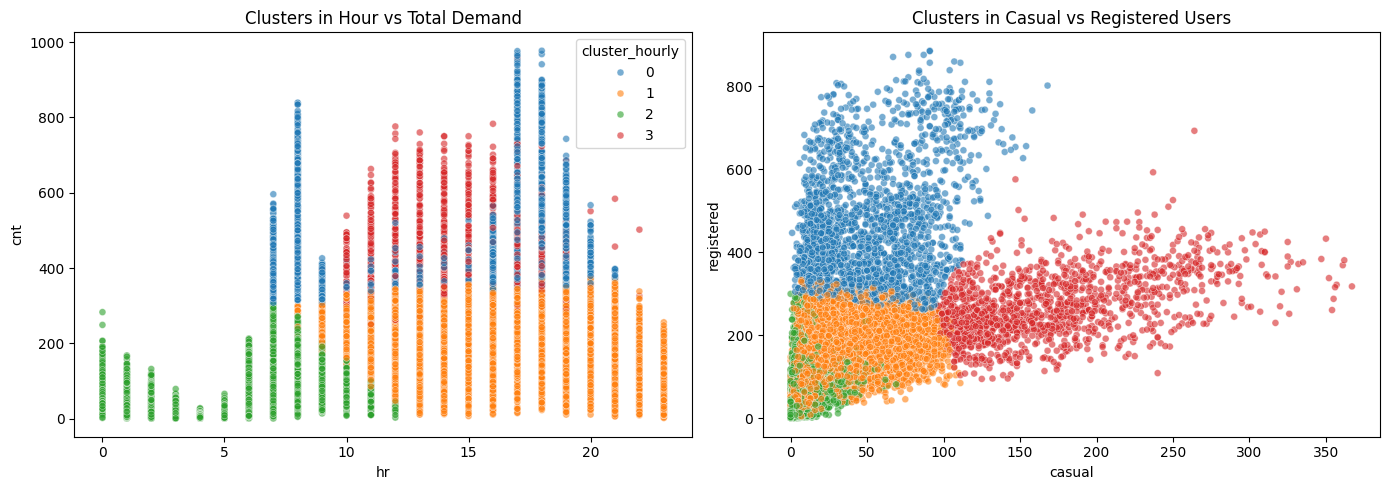

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="hr", y="cnt",
    hue="cluster_hourly", palette="tab10", alpha=0.6, s=25, ax=axes[0]
)
axes[0].set_title("Clusters in Hour vs Total Demand")

sns.scatterplot(
    data=df_clean, x="casual", y="registered",
    hue="cluster_hourly", palette="tab10", alpha=0.6, s=25, ax=axes[1], legend=False
)
axes[1].set_title("Clusters in Casual vs Registered Users")

plt.tight_layout()
plt.show()


### Hourly demand composition (casual vs registered)
This plot shows average hourly demand split by user type to highlight commute-driven (registered) and leisure-driven (casual) behavior.

Silhouette by k: {2: np.float64(0.4252), 3: np.float64(0.321), 4: np.float64(0.3235), 5: np.float64(0.3373), 6: np.float64(0.3587), 7: np.float64(0.3587)}
Best k: 2

Seasonality cluster profiles:
                cnt_mean  casual_mean  registered_mean  temp_mean  hum_mean
season_cluster                                                             
1                 329.24        71.53           257.70       0.63      0.56
0                  98.33        12.34            85.99       0.41      0.67


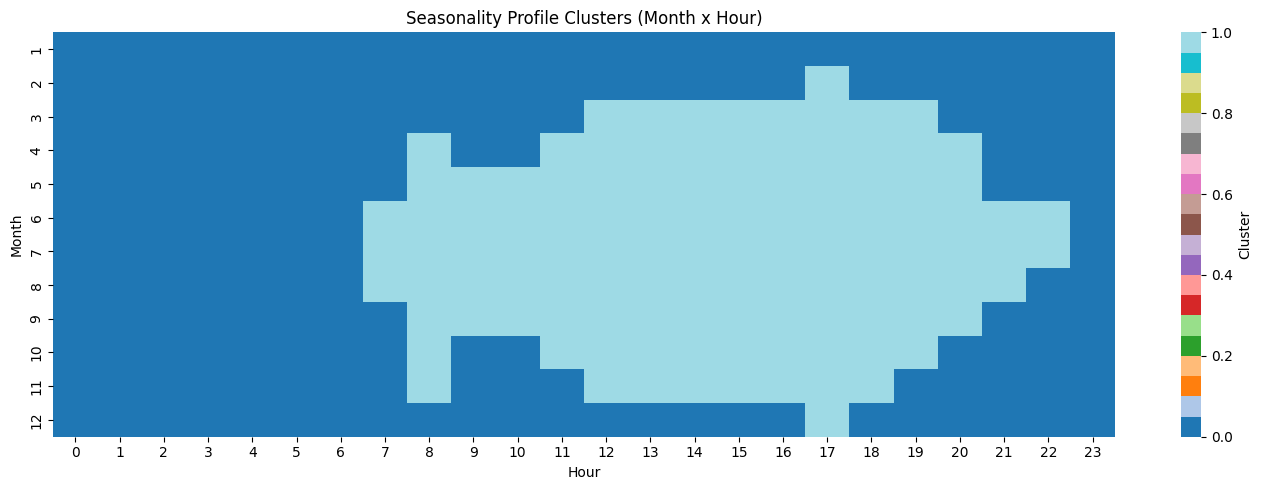

In [ ]:
seasonality = (
    df_clean
    .groupby(["mnth", "hr"], as_index=False)
    .agg(
        cnt_mean=("cnt", "mean"),
        casual_mean=("casual", "mean"),
        registered_mean=("registered", "mean"),
        temp_mean=("temp", "mean"),
        hum_mean=("hum", "mean"),
    )
)
features = ["cnt_mean", "casual_mean", "registered_mean", "temp_mean", "hum_mean"]
X_season = StandardScaler().fit_transform(seasonality[features])

# Choose k by silhouette
k_values = range(2, 8)
sil_scores = []
for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_season)
    sil_scores.append(silhouette_score(X_season, labels))

best_k = k_values[int(np.argmax(sil_scores))]
print("Silhouette by k:", dict(zip(k_values, np.round(sil_scores, 4))))
print("Best k:", best_k)

# Fit final model
km_season = KMeans(n_clusters=best_k, random_state=42, n_init=20)
seasonality["season_cluster"] = km_season.fit_predict(X_season)

# Cluster profiles
cluster_profile = (
    seasonality
    .groupby("season_cluster")[features]
    .mean()
    .round(2)
    .sort_values("cnt_mean", ascending=False)
)
print("\nSeasonality cluster profiles:")
print(cluster_profile)

# Visualize monthxhour cluster map
pivot_clusters = seasonality.pivot(index="mnth", columns="hr", values="season_cluster")
plt.figure(figsize=(14, 5))
sns.heatmap(pivot_clusters, cmap="tab20", cbar_kws={"label": "Cluster"})
plt.title("Seasonality Profile Clusters (Month x Hour)")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

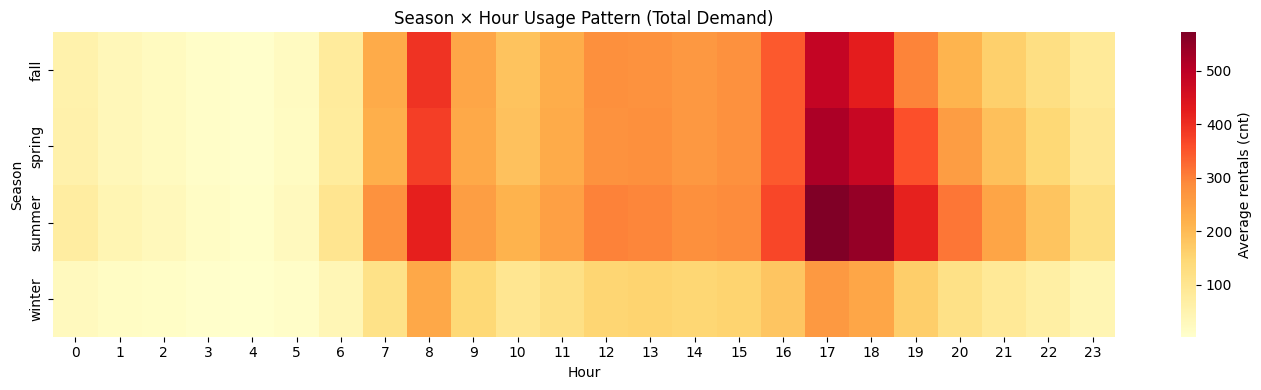

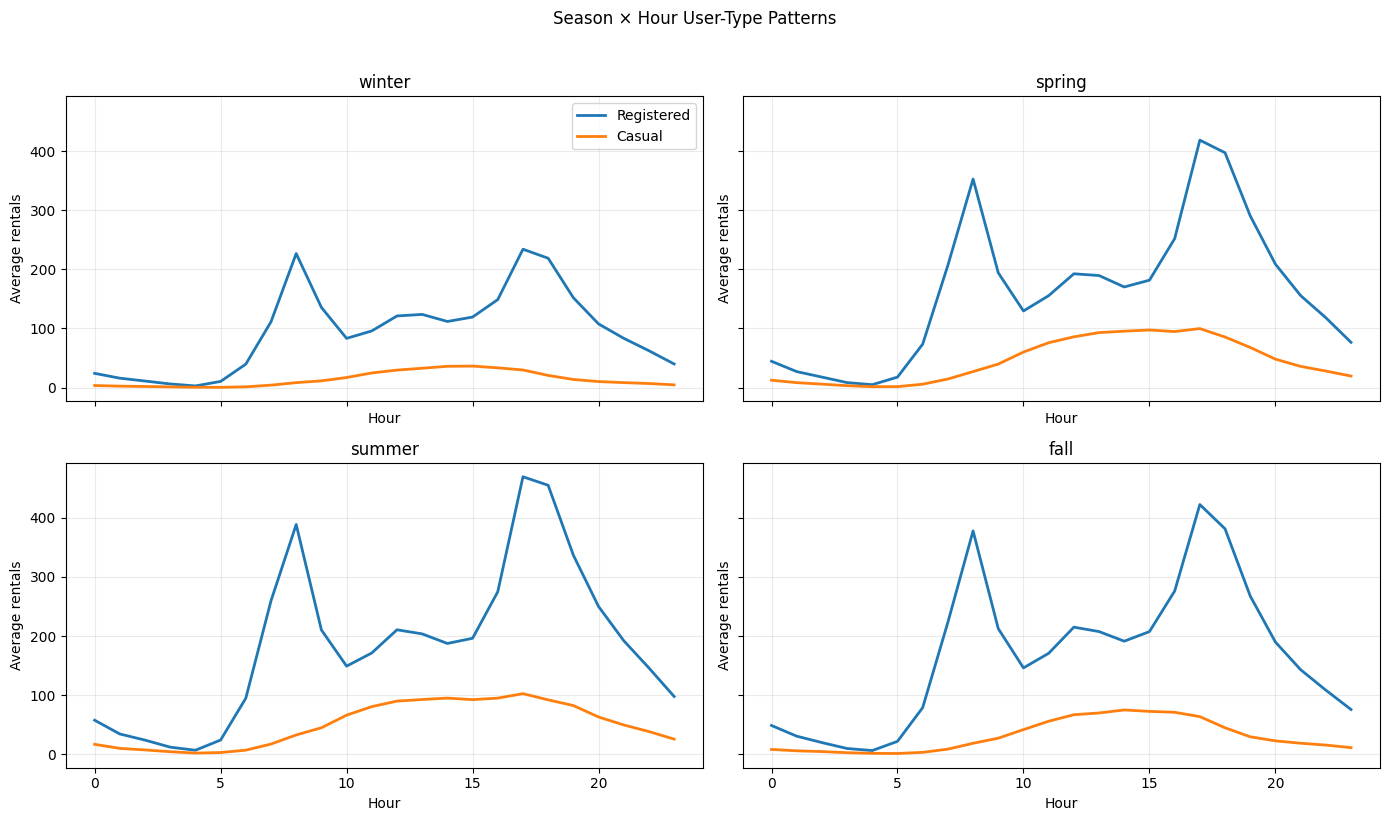

In [ ]:

# Season x Hour usage patterns (real demand)
season_map = season_labels
season_order = ["winter", "spring", "summer", "fall"]

season_hour = (
    df_clean.assign(season_name=df_clean["season"].map(season_map))
    .groupby(["season_name", "hr"], as_index=False)
    .agg(
        cnt_mean=("cnt", "mean"),
        casual_mean=("casual", "mean"),
        registered_mean=("registered", "mean"),
    )
)

#  Heatmap: total usage pattern by season and hour
pivot_cnt = (
    season_hour
    .pivot(index="season_name", columns="hr", values="cnt_mean")
)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_cnt, cmap="YlOrRd", cbar_kws={"label": "Average rentals (cnt)"})
plt.title("Season × Hour Usage Pattern (Total Demand)")
plt.xlabel("Hour")
plt.ylabel("Season")
plt.tight_layout()
plt.show()

# Lines: casual vs registered by hour for each season
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, s in enumerate(season_order):
    d = season_hour[season_hour["season_name"] == s]
    axes[i].plot(d["hr"], d["registered_mean"], label="Registered", linewidth=2)
    axes[i].plot(d["hr"], d["casual_mean"], label="Casual", linewidth=2)
    axes[i].set_title(s)
    axes[i].set_xlabel("Hour")
    axes[i].set_ylabel("Average rentals")
    axes[i].grid(alpha=0.25)

axes[0].legend()
plt.suptitle("Season × Hour User-Type Patterns", y=1.02)
plt.tight_layout()
plt.show()


## 3. Module 2 — Graph-Based Analysis

In [16]:
import networkx as nx

# Build graph
G = nx.Graph()

ModuleNotFoundError: No module named 'networkx'

## 4. Module 3 — Pattern / Text Mining

In [ ]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
